In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [61]:
folder_path = r"D:\PTDLKinhDoanh\Dataset\all_fuels_data.csv"
df = pd.read_csv(folder_path) 

print(df.head()) 

  ticker  commodity       date       open       high        low      close  \
0   CL=F  Crude Oil  8/23/2000  31.950001  32.799999  31.950001  32.049999   
1   CL=F  Crude Oil  8/24/2000  31.900000  32.240002  31.400000  31.629999   
2   CL=F  Crude Oil  8/25/2000  31.700001  32.099998  31.320000  32.049999   
3   CL=F  Crude Oil  8/28/2000  32.040001  32.919998  31.860001  32.869999   
4   CL=F  Crude Oil  8/29/2000  32.820000  33.029999  32.560001  32.720001   

   volume  
0   79385  
1   72978  
2   44601  
3   46770  
4   49131  


In [62]:
print("\n=== Các loại hàng hóa có trong dữ liệu ===")
print(df['commodity'].unique())


=== Các loại hàng hóa có trong dữ liệu ===
['Crude Oil' 'Heating Oil' 'Natural Gas' 'RBOB Gasoline' 'Brent Crude Oil']


In [63]:
print(df.columns)


Index(['ticker', 'commodity', 'date', 'open', 'high', 'low', 'close',
       'volume'],
      dtype='object')


In [64]:
print(df.info())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28075 entries, 0 to 28074
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ticker     28075 non-null  object 
 1   commodity  28075 non-null  object 
 2   date       28075 non-null  object 
 3   open       28075 non-null  float64
 4   high       28075 non-null  float64
 5   low        28075 non-null  float64
 6   close      28075 non-null  float64
 7   volume     28075 non-null  int64  
dtypes: float64(4), int64(1), object(3)
memory usage: 1.7+ MB
None


In [65]:
# 5. Kiểm tra missing values
print("\nMissing values:\n", df.isnull().sum())


Missing values:
 ticker       0
commodity    0
date         0
open         0
high         0
low          0
close        0
volume       0
dtype: int64


In [67]:
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)
df.sort_index(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 28075 entries, 2000-08-23 to 2024-06-24
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ticker     28075 non-null  object 
 1   commodity  28075 non-null  object 
 2   open       28075 non-null  float64
 3   high       28075 non-null  float64
 4   low        28075 non-null  float64
 5   close      28075 non-null  float64
 6   volume     28075 non-null  int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 1.7+ MB


In [68]:
df.head()

,ticker,commodity,open,high,low,close,volume
date,,,,,,,
2000-08-23,CL=F,Crude Oil,31.950001,32.799999,31.950001,32.049999,79385
2000-08-24,CL=F,Crude Oil,31.900000,32.240002,31.400000,31.629999,72978
2000-08-25,CL=F,Crude Oil,31.700001,32.099998,31.320000,32.049999,44601
2000-08-28,CL=F,Crude Oil,32.040001,32.919998,31.860001,32.869999,46770
2000-08-29,CL=F,Crude Oil,32.820000,33.029999,32.560001,32.720001,49131


In [70]:

# Trích xuất thêm thông tin từ ngày
df['year'] = df.index.year
df['month'] = df.index.month
df['day'] = df.index.day
df['day_of_week'] = df.index.dayofweek

In [71]:
df.describe()

,open,high,low,close,volume,year,month,day,day_of_week
count,28075.000000,28075.000000,28075.000000,28075.000000,2.807500e+04,28075.000000,28075.000000,28075.000000,28075.000000
mean,27.288994,27.680580,26.873389,27.287224,1.059926e+05,2012.626180,6.526803,15.714871,2.021585
std,36.085625,36.540236,35.599243,36.089001,1.484400e+05,6.724098,3.437069,8.753364,1.397860
min,-14.000000,0.507000,-40.320000,-37.630001,0.000000e+00,2000.000000,1.000000,1.000000,0.000000
25%,2.031000,2.060550,1.998200,2.031250,2.641100e+04,2007.000000,4.000000,8.000000,1.000000
50%,3.374000,3.450000,3.301000,3.375900,4.903300e+04,2013.000000,7.000000,16.000000,2.000000
75%,54.895000,55.745001,53.910000,54.900000,1.147245e+05,2018.000000,10.000000,23.000000,3.000000
max,146.080002,147.429993,144.270004,146.080002,2.288230e+06,2024.000000,12.000000,31.000000,4.000000


In [73]:
columns = ['ticker', 'commodity', 'open', 'high', 'low', 'close', 'volume']

for col in columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        print(f"Giá trị {col} nhỏ hơn hoặc bằng 0:", (df[col] <= 0).sum())
    else:
        print(f"Cột {col} không phải số, bỏ qua.")

Cột ticker không phải số, bỏ qua.
Cột commodity không phải số, bỏ qua.
Giá trị open nhỏ hơn hoặc bằng 0: 1
Giá trị high nhỏ hơn hoặc bằng 0: 0
Giá trị low nhỏ hơn hoặc bằng 0: 2
Giá trị close nhỏ hơn hoặc bằng 0: 1
Giá trị volume nhỏ hơn hoặc bằng 0: 107


In [12]:
for col in ['open', 'high', 'low', 'close']:
    df[col] = df[col].apply(lambda x: x if x > 0 else df[col].mean())  # Thay bằng giá trị trung bình của cột


In [13]:
columns = ['date', 'ticker', 'commodity', 'open', 'high', 'low', 'close', 'volume']

for col in columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        print(f"Giá trị {col} nhỏ hơn hoặc bằng 0:", (df[col] <= 0).sum())
    else:
        print(f"Cột {col} không phải số, bỏ qua.")


Cột date không phải số, bỏ qua.
Cột ticker không phải số, bỏ qua.
Cột commodity không phải số, bỏ qua.
Giá trị open nhỏ hơn hoặc bằng 0: 0
Giá trị high nhỏ hơn hoặc bằng 0: 0
Giá trị low nhỏ hơn hoặc bằng 0: 0
Giá trị close nhỏ hơn hoặc bằng 0: 0
Giá trị volume nhỏ hơn hoặc bằng 0: 107


In [74]:
df.describe()

,open,high,low,close,volume,year,month,day,day_of_week
count,28075.000000,28075.000000,28075.000000,28075.000000,2.807500e+04,28075.000000,28075.000000,28075.000000,28075.000000
mean,27.288994,27.680580,26.873389,27.287224,1.059926e+05,2012.626180,6.526803,15.714871,2.021585
std,36.085625,36.540236,35.599243,36.089001,1.484400e+05,6.724098,3.437069,8.753364,1.397860
min,-14.000000,0.507000,-40.320000,-37.630001,0.000000e+00,2000.000000,1.000000,1.000000,0.000000
25%,2.031000,2.060550,1.998200,2.031250,2.641100e+04,2007.000000,4.000000,8.000000,1.000000
50%,3.374000,3.450000,3.301000,3.375900,4.903300e+04,2013.000000,7.000000,16.000000,2.000000
75%,54.895000,55.745001,53.910000,54.900000,1.147245e+05,2018.000000,10.000000,23.000000,3.000000
max,146.080002,147.429993,144.270004,146.080002,2.288230e+06,2024.000000,12.000000,31.000000,4.000000


In [75]:
# Nếu lỡ đánh date thành index, bỏ index cho cột date bằng cách sau
if df.index.name == 'date':
    df.reset_index(inplace=True)

In [76]:
# 2. Khởi tạo dict để chứa 5 DataFrame
series_dict = {}

# 3. Group và xử lý riêng cho từng commodity
for comm, grp in df.groupby('commodity'):
    # a) Chuyển đảm bảo 'date' là datetime (parse_dates đã làm, nhưng thêm cho chắc)
    grp['date'] = pd.to_datetime(grp['date'])
    
    # b) Sort theo ngày rồi đặt làm index
    grp = grp.sort_values('date').set_index('date')
    
    # c) (Tuỳ chọn) Reindex để có đủ khung ngày (chỉ dùng cho holt-winters, ARMIA, SARIMA,... )
    #Nếu bạn xác định dùng Holt-Winters và forecast đều mỗi ngày, thì nên reindex.
    #Nếu bạn chỉ muốn phân tích theo ngày giao dịch thật (ví dụ xem xu hướng mà không dự đoán theo ngày) thì không cần reindex.
    
    # full_idx = pd.date_range(start=grp.index.min(), end=grp.index.max(), freq='D')
    # grp = grp.reindex(full_idx)
    
    # d) Lưu lại DataFrame đã set_index
    series_dict[comm] = grp

# 4. Truy cập:
#   - Crude Oil:   series_dict['Crude Oil']
#   - Brent:       series_dict['Brent Crude Oil']
#   - Natural Gas: series_dict['Natural Gas']
#   - … v.v.



In [77]:

series_dict['Crude Oil']['date'] = series_dict['Crude Oil'].index
series_dict['Crude Oil'].reset_index(drop=True, inplace=True)

In [78]:
# Sắp xếp DataFrame theo cột 'date'
series_dict['Crude Oil'] = series_dict['Crude Oil'].sort_values(by='date')

In [79]:
series_dict['Crude Oil']

,ticker,commodity,open,high,low,close,volume,year,month,day,day_of_week,date
0,CL=F,Crude Oil,31.950001,32.799999,31.950001,32.049999,79385,2000,8,23,2,2000-08-23
1,CL=F,Crude Oil,31.900000,32.240002,31.400000,31.629999,72978,2000,8,24,3,2000-08-24
2,CL=F,Crude Oil,31.700001,32.099998,31.320000,32.049999,44601,2000,8,25,4,2000-08-25
3,CL=F,Crude Oil,32.040001,32.919998,31.860001,32.869999,46770,2000,8,28,0,2000-08-28
4,CL=F,Crude Oil,32.820000,33.029999,32.560001,32.720001,49131,2000,8,29,1,2000-08-29
...,...,...,...,...,...,...,...,...,...,...,...,...
5979,CL=F,Crude Oil,78.480003,80.660004,77.980003,80.330002,126733,2024,6,17,0,2024-06-17
5980,CL=F,Crude Oil,80.430000,81.669998,79.769997,81.570000,140709,2024,6,18,1,2024-06-18
5981,CL=F,Crude Oil,81.519997,82.410004,81.129997,82.169998,420499,2024,6,20,3,2024-06-20
5982,CL=F,Crude Oil,81.269997,81.790001,80.349998,80.730003,290500,2024,6,21,4,2024-06-21


In [80]:
# Selecting features and target
features = ['open', 'high', 'low', 'volume', 'year', 'month', 'day']
target = 'close'

# Splitting the data into features (X) and target (y)
X = series_dict['Crude Oil'][features]
y = series_dict['Crude Oil'][target]

# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:


model = CatBoostRegressor(
    iterations=1000,
    depth=6,
    learning_rate=0.1, #0.05
    loss_function='RMSE',
    verbose=0
)


# Training the model
model.fit(X_train, y_train)

# Making predictions on the test data
y_pred = model.predict(X_test)

In [82]:
from sklearn.metrics import mean_absolute_error

# Calculating Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f'Mean Absolute Error: {mae}')
print(f"📌 - Mean Squared Error (MSE): {mse:.4f}")
print(f"📌 - Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"📌 - R-squared (R²): {r2:.4f}")

Mean Absolute Error: 0.5554810743685501
📌 - Mean Squared Error (MSE): 0.8414
📌 - Root Mean Squared Error (RMSE): 0.9173
📌 - R-squared (R²): 0.9987


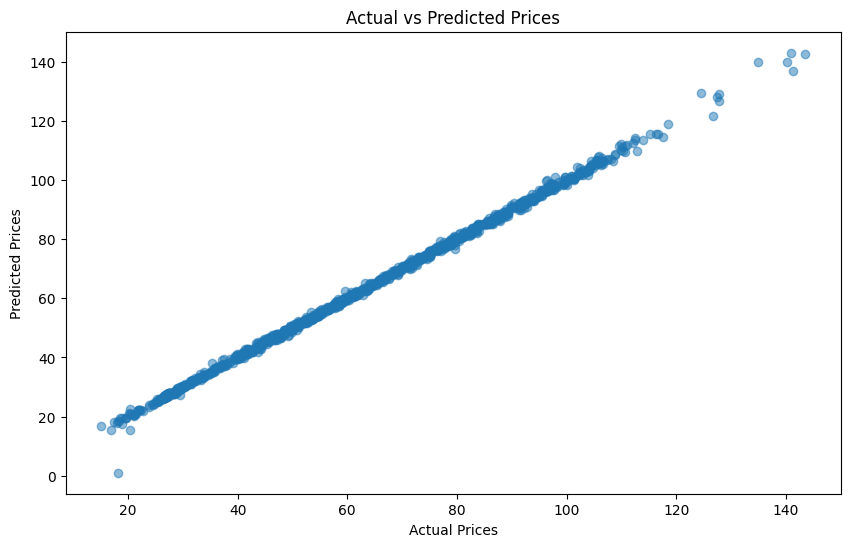

In [83]:
# Visualizing the predicted vs actual prices
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()


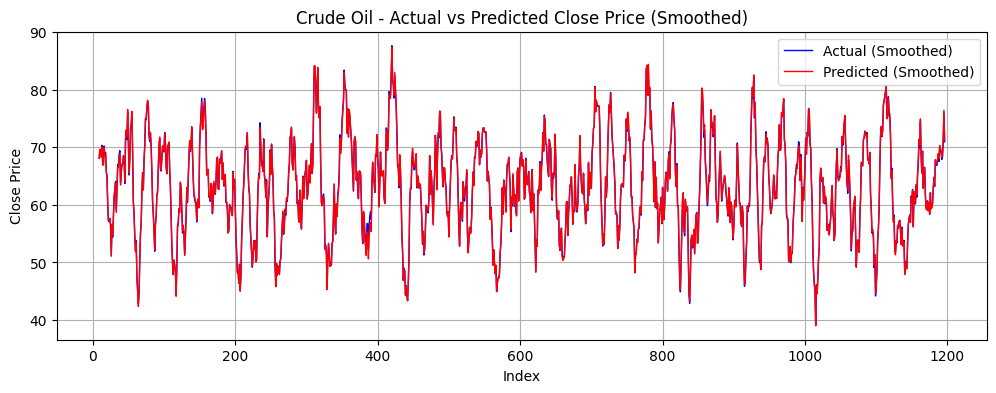

In [84]:
# Tính trung bình động
window_size = 10  # Kích thước cửa sổ
y_test_smoothed = y_test.reset_index(drop=True).rolling(window=window_size).mean()
y_pred_smoothed = pd.Series(y_pred).rolling(window=window_size).mean()

# Vẽ lại biểu đồ
plt.figure(figsize=(12, 4))
plt.plot(y_test_smoothed, label='Actual (Smoothed)', color='blue', linewidth=1)
plt.plot(y_pred_smoothed, label='Predicted (Smoothed)', color='red', linewidth=1)
plt.title('Crude Oil - Actual vs Predicted Close Price (Smoothed)')
plt.xlabel('Index')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()

In [89]:
!pip install yfinance

  Using cached yfinance-0.2.56-py2.py3-none-any.whl (113 kB)
  Using cached frozendict-2.4.6-cp310-cp310-win_amd64.whl (37 kB)
  Using cached multitasking-0.0.11-py3-none-any.whl (8.5 kB)
  Using cached peewee-3.17.9.tar.gz (3.0 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for peewee: filename=peewee-3.17.9-py3-none-any.whl size=139127 sha256=0ede43b722dcf115f6d2a58558f450f20edd66e5f89bce7cb30490008ca60ede
  Stored in directory: c:\users\15520\appdata\local\pip\cache\wheels\fd\fd\5e\90b9ec95da4fd6c96237b580ce74f89d6bdea547ad151ab5f4
Successfully built peewee



[notice] A new release of pip is available: 23.0.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [90]:
!pip install ipywidgets

     ---------------------------------------- 0.0/139.8 kB ? eta -:--:--
     --------------------------- ---------- 102.4/139.8 kB 2.9 MB/s eta 0:00:01
     -------------------------------------- 139.8/139.8 kB 2.1 MB/s eta 0:00:00
     ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
     --- ------------------------------------ 0.2/2.2 MB 5.6 MB/s eta 0:00:01
     ------- -------------------------------- 0.4/2.2 MB 4.9 MB/s eta 0:00:01
     ------------ --------------------------- 0.7/2.2 MB 5.5 MB/s eta 0:00:01
     ----------------- ---------------------- 1.0/2.2 MB 5.5 MB/s eta 0:00:01
     ----------------------- ---------------- 1.3/2.2 MB 5.9 MB/s eta 0:00:01
     ------------------------------ --------- 1.7/2.2 MB 6.2 MB/s eta 0:00:01
     ----------------------------------- ---- 2.0/2.2 MB 6.2 MB/s eta 0:00:01
     -------------------------------------- - 2.1/2.2 MB 5.8 MB/s eta 0:00:01
     ---------------------------------------- 2.2/2.2 MB 5.6 MB/s eta 0:


[notice] A new release of pip is available: 23.0.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [91]:
import yfinance as yf
import ipywidgets as widgets

In [92]:
# Load the dataset from Yahoo Finance
ticker = 'AAPL'
data = yf.download(ticker, start="2015-01-01", end="2020-12-31")

# Display the first few rows of the dataset
data.head()


YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-01-02,24.320436,24.789806,23.879985,24.778683,212818400
2015-01-05,23.635284,24.169164,23.448427,24.089082,257142000
2015-01-06,23.637510,23.897776,23.274916,23.699796,263188400
2015-01-07,23.968962,24.069063,23.735389,23.846614,160423600
2015-01-08,24.889906,24.947743,24.180291,24.298190,237458000
